In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import yaml
import os
from catboost import Pool
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from src.feature_generation.make_features import make_features_and_save

config_path = 'configs/features_config_30d.yaml'
with open(config_path, 'r') as config_file:
        config = yaml.safe_load(config_file)

In [29]:
countries_train = ["Dem_Rep_Korea",
                       "Russian_Federation",
                       "Finland",
                       "Norway",
                       "Sweden",
                       "Denmark",
                       "Lithuania",
                       "Latvia",
                       "Estonia",
                       "Poland",
                       "Czech_Republic",
                       "Germany",
                       "Hungary",
                       "Slovakia",
                       "Belarus",
                       "Ukraine",
                       "Moldova",
                       "Romania",
                       "Bulgaria",
                       "Albania",
                       "Montenegro",
                       "Macedonia_Former_Yugoslav_Republic_of",
                       "Kosovo",
                       "Serbia",
                       "Croatia",
                       "Bosnia_and_Herzegovina",
                       "Slovenia",
                       "Greece",
                       "Turkey",
                       "Georgia",
                       "Azerbaijan",
                        "Armenia",
                       "Kazakhstan",
                       "Kyrgyzstan",
                       "Tajikistan",
                       "Mongolia",
                       "China",
                       "Japan",
                       "Republic_of_Korea"
                       ]

countries_df_list = []

current_df_path = 'data/saved_features_boost/train_test_features_30d_all_extended_north_14cb.parquet'

if not os.path.exists(current_df_path):
    for country in countries_train:
        df_country = pd.read_parquet(f'data/saved_features/train_test_features_30d_{country}.parquet')
        if country == "Ukraine":
            # Remove data after 2022-02-24 because of the war
            df_country = df_country[df_country['datetime'] < '2022-02-24']
        countries_df_list.append(df_country)

    df = pd.concat(countries_df_list)
    df = df.sort_values('datetime')
    #save final_df
    df.to_parquet(current_df_path)
else:
    df = pd.read_parquet(current_df_path)



with open(config['selected_feature_columns_path'], 'r') as f:
    selected_features = [line.strip() for line in f.readlines()]

#Check if all selected columns are in the dataframe
# assert all(col in df.columns for col in selected_features)


In [30]:
target_col = 'count'
df['population'] = df['population'].fillna(0)
df['population'] = df['population'].astype(int)

cat_features = config['cat_features']
numerical_cat_features = config['numerical_cat_features']

for col in cat_features:
    if col in numerical_cat_features:
        df[col] = df[col].astype(int)
    else:
        df[col] = df[col].astype(str)

X = df.drop(columns=[target_col])
y = df[target_col]
#X  = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

print(f"Train start year: {X_train['datetime'].min().year}")
print(f"Test start year: {X_test['datetime'].min().year}")
# Here Validation used as part of Train set, for prediction-ready model

Train start year: 2000
Test start year: 2021


In [10]:
y_train_binary = (y_train >0).astype(int)
y_test_binary = (y_test > 0).astype(int)

print(f"Train class balance: {y_train_binary.value_counts()}")
print(f"Test class balance: {y_test_binary.value_counts()}")


model_clf = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=0.35,
    bagging_temperature=0.96,
    min_data_in_leaf=80, 
    loss_function='Logloss',
    class_weights=[1,  4.0], 
    verbose=50, 
    ignored_features=["datetime", "day", "latitude", "longitude", "year"],
    cat_features=cat_features,
    feature_weights={'ecoregion_name':0.3,
                     "lat_rounded":0.3,
                     "lon_rounded":0.3,
                     },
    #task_type='GPU',
)

model_clf.fit(X_train, y_train_binary)

Train class balance: count
0    1542402
1     231908
Name: count, dtype: int64
Test class balance: count
0    275722
1     37392
Name: count, dtype: int64
0:	learn: 0.6680110	total: 542ms	remaining: 9m 1s
50:	learn: 0.3587322	total: 22.6s	remaining: 7m
100:	learn: 0.3186669	total: 45.5s	remaining: 6m 45s
150:	learn: 0.3015441	total: 1m 8s	remaining: 6m 24s
200:	learn: 0.2897312	total: 1m 30s	remaining: 6m
250:	learn: 0.2809285	total: 1m 53s	remaining: 5m 38s
300:	learn: 0.2734351	total: 2m 16s	remaining: 5m 16s
350:	learn: 0.2677818	total: 2m 38s	remaining: 4m 53s
400:	learn: 0.2623354	total: 3m 1s	remaining: 4m 31s
450:	learn: 0.2579053	total: 3m 24s	remaining: 4m 8s
500:	learn: 0.2537614	total: 3m 47s	remaining: 3m 46s
550:	learn: 0.2499113	total: 4m 10s	remaining: 3m 24s
600:	learn: 0.2460646	total: 4m 33s	remaining: 3m 1s
650:	learn: 0.2429975	total: 4m 56s	remaining: 2m 38s
700:	learn: 0.2400109	total: 5m 19s	remaining: 2m 16s
750:	learn: 0.2369385	total: 5m 42s	remaining: 1m 53s


In [11]:
# model_clf.save_model(config['model_path'])

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Train metrics
y_pred_binary = model_clf.predict(X_train)
accuracy = accuracy_score(y_train_binary, y_pred_binary)
precision = precision_score(y_train_binary, y_pred_binary)
recall = recall_score(y_train_binary, y_pred_binary)
f1 = f1_score(y_train_binary, y_pred_binary)  
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1: {f1}')


Accuracy: 0.9149134029566423
Precision: 0.6211182540822678
Recall: 0.8948936647291167
F1: 0.733285515408914


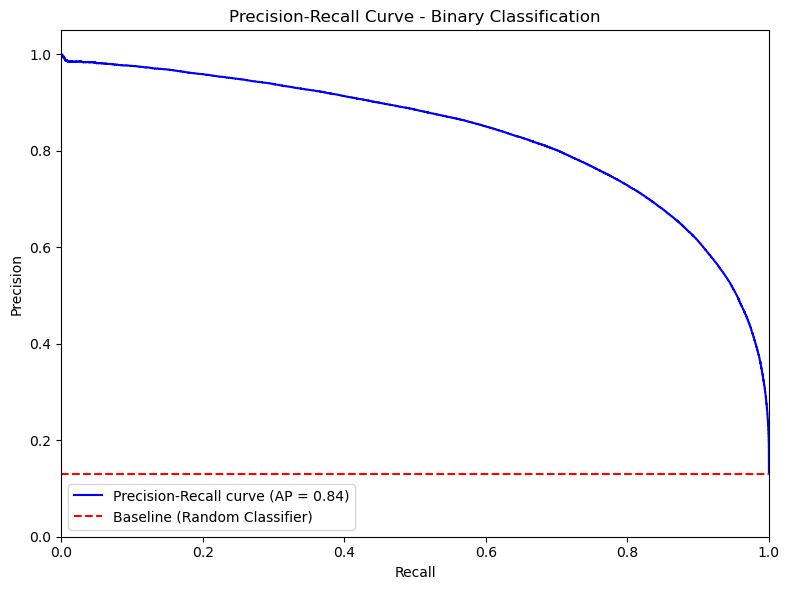

TRAIN PRECISION RECALL CURVE


In [13]:
from src.utils.plot_utils import plot_precision_recall_curve
y_pred_proba = model_clf.predict_proba(X_train)
plot_precision_recall_curve(y_train_binary, y_pred_proba)
print("TRAIN PRECISION RECALL CURVE")

In [14]:
y_pred_binary = model_clf.predict(X_test)

accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)  

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1: {f1}')

Accuracy: 0.9126867530675729
Precision: 0.5893901940210916
Recall: 0.8863393239195549
F1: 0.7079884216485265


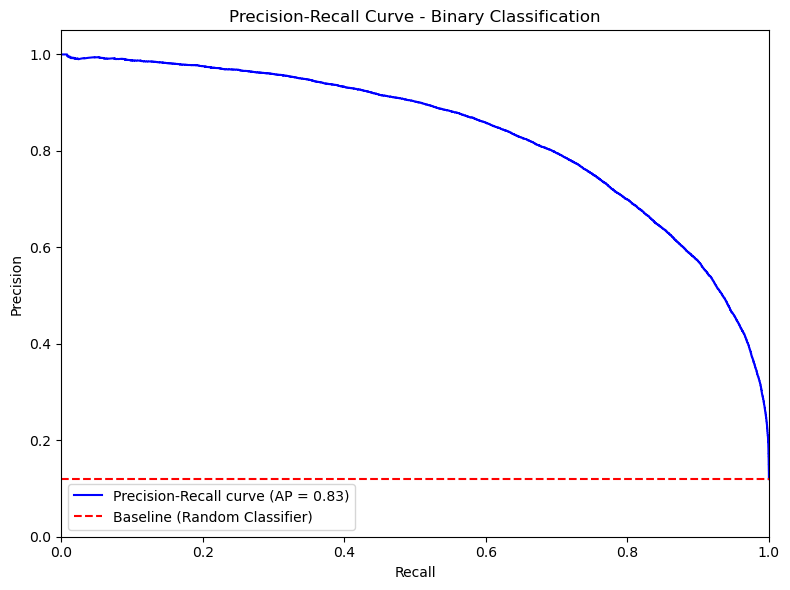

In [15]:
from src.utils.plot_utils import plot_precision_recall_curve
y_pred_proba = model_clf.predict_proba(X_test)
plot_precision_recall_curve(y_test_binary, y_pred_proba)

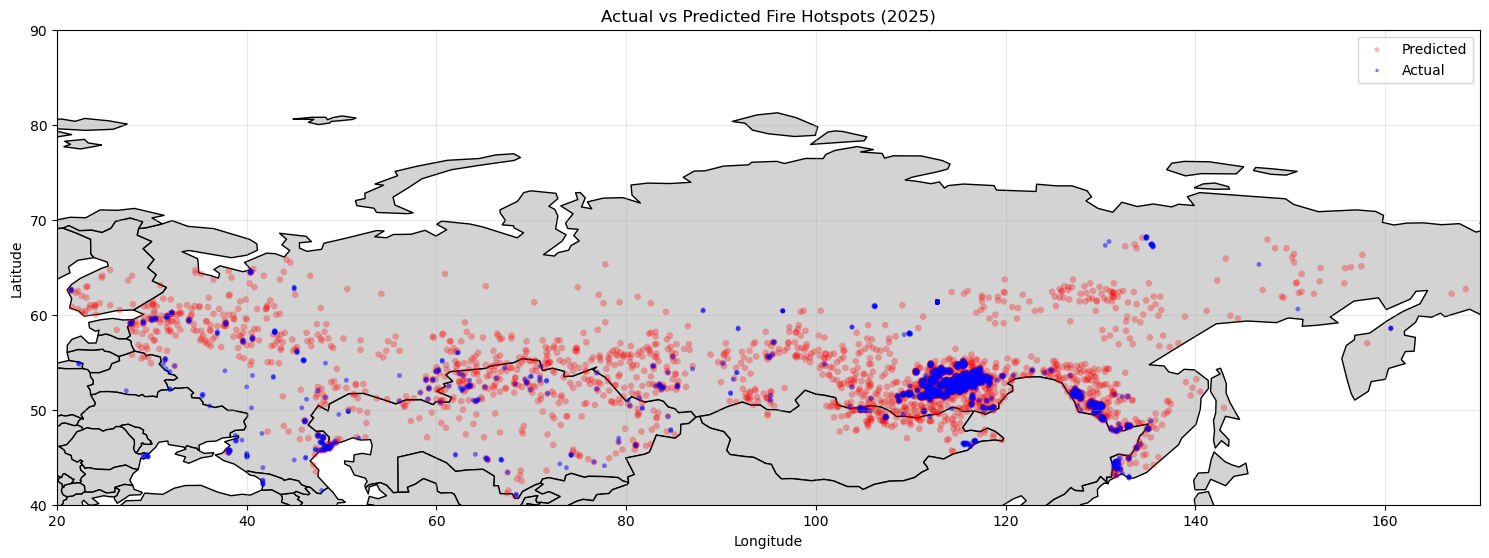

In [16]:
year = 2025
y_pred_binary = model_clf.predict(X_test)

assert len(X_test) == len(y_test_binary) == len(y_pred_binary)

year_mask = np.array(pd.to_datetime(X_test['datetime']).dt.year == year)
plt.style.use('seaborn-v0_8-bright')
fig, ax = plt.subplots(figsize=(15, 10))
world = gpd.read_file('data/countries')
world.plot(ax=ax, color='lightgrey', edgecolor='black')
lat = X_test['lat_rounded'][year_mask]
lon = X_test['lon_rounded'][year_mask]
pred_count = y_pred_binary[year_mask]
actual_count = y_test_binary[year_mask]

scatter_pred = plt.scatter(lon, 
                         lat,
                         c='red', s=pred_count * 23, 
                         alpha=0.3, label='Predicted', 
                         edgecolors='none')

scatter_actual = plt.scatter(lon, 
                             lat,
                           c='blue', s=actual_count * 12, 
                           alpha=0.5, label='Actual',
                           edgecolors='none')

ax.set_xlim(20, 170)
ax.set_ylim(40, 90)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Actual vs Predicted Fire Hotspots ({year})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

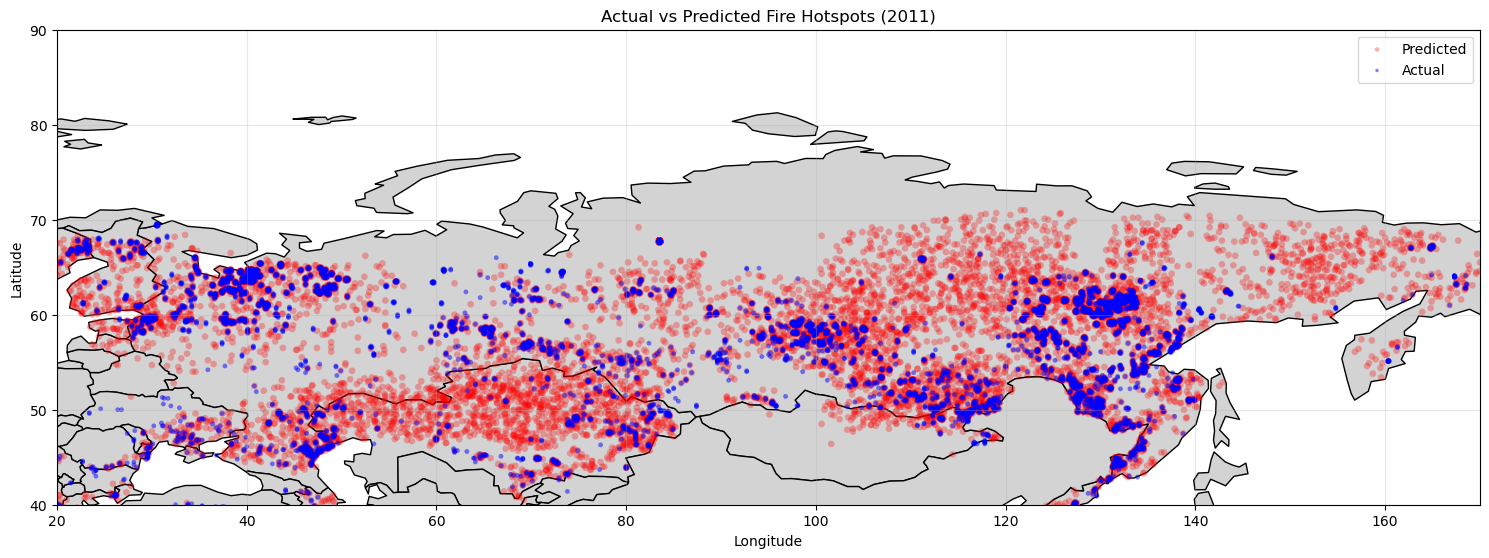

In [17]:
year = 2011

y_pred_binary = model_clf.predict(X_train)
assert len(X_train) == len(y_train_binary) == len(y_pred_binary)

year_mask = np.array(pd.to_datetime(X_train['datetime']).dt.year == year)
plt.style.use('seaborn-v0_8-bright')
fig, ax = plt.subplots(figsize=(15, 10))
world = gpd.read_file('data/countries')
world.plot(ax=ax, color='lightgrey', edgecolor='black')
lat = X_train['lat_rounded'][year_mask]
lon = X_train['lon_rounded'][year_mask]
pred_count = y_pred_binary[year_mask]
actual_count = y_train_binary[year_mask]

scatter_pred = plt.scatter(lon, 
                         lat,
                         c='red', s=pred_count * 23, 
                         alpha=0.3, label='Predicted', 
                         edgecolors='none')

scatter_actual = plt.scatter(lon, 
                             lat,
                           c='blue', s=actual_count * 12, 
                           alpha=0.5, label='Actual',
                           edgecolors='none')

ax.set_xlim(20, 170)
ax.set_ylim(40, 90)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Actual vs Predicted Fire Hotspots ({year})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [18]:
# Feature importance
feature_importance = model_clf.get_feature_importance()
feature_names = model_clf.feature_names_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
feature_importance_df.head(50)

,feature,importance
223,fire_index_fwinx_mean,5.482162
166,stl1_trend_slope_90,4.846911
232,population,3.990003
241,tvh,3.454679
242,tvl,3.129521
3,month,2.942667
82,d2m_min_120,2.187995
244,ecoregion_name,1.844574
225,fire_index_fwinx_median,1.789397
102,d2m_trend_slope_90,1.739610


In [19]:
for col in feature_importance_df['feature']:
    print(col)

fire_index_fwinx_mean
stl1_trend_slope_90
population
tvh
tvl
month
d2m_min_120
ecoregion_name
fire_index_fwinx_median
d2m_trend_slope_90
lai_hv
distance_to_coast_dilated_km
t2m_median_120
t2m_max_90
stl1_std_120
d2m_std_120
tp_min_30
fire_index_ffmcode_median
fire_index_fdsrte_median
fire_index_ffmcode_max
stl1_median_7
t2m_pct_change_90
fire_index_drtcode_mean
fire_index_drtcode_max
fire_index_drtcode_median
elevation_max_0.2deg
stl1_mean_120
elevation_min_0.2deg
stl1_std_30
stl1_std_90
sdfor
fire_index_drtcode_min
t2m_trend_slope_90
distance_to_coast_km
z
tp_median_120
tp_max_30
t2m_mean_7
t2m_ewm_7
landseamask
t2m_max_30
t2m_min_14
stl1_ewm_7
lat_rounded
t2m_mean_30
t2m_diff_90
stl1_trend_intercept_90
stl1_mean_90
t2m_median_90
d2m_mean_30
t2m_max_7
stl1_min_120
tp_ewm_7
t2m_std_120
stl1_trend_slope_21
elevation_min_0.1deg
lai_lv
fire_index_drtcode_std
stl1_ewm_120
tp_mean_120
t2m_ewm_30
fire_index_fdsrte_std
d2m_max_90
t2m_diff_7
stl1_median_14
d2m_max_30
t2m_median_7
t2m_ewm_14
el

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Prepare the data for logistic regression
target_col = 'count'
df['population'] = df['population'].fillna(0)
df['population'] = df['population'].astype(int)

cat_features = config['cat_features']
numerical_cat_features = config['numerical_cat_features']

for col in cat_features:
    if col in numerical_cat_features:
        df[col] = df[col].astype(int)
    else:
        df[col] = df[col].astype(str)

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

print(f"Train start year: {X_train['datetime'].min().year}")
print(f"Test start year: {X_test['datetime'].min().year}")

# Create binary targets
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

print(f"Train class balance: {y_train_binary.value_counts()}")
print(f"Test class balance: {y_test_binary.value_counts()}")

# Features to ignore
ignored_features = ["datetime", "day", "latitude", "longitude", "year"]

# Identify high cardinality categorical features
high_cardinality_threshold = 60
high_cardinality_features = []
low_cardinality_features = []

for col in config['cat_features']:
    if col not in ignored_features:
        n_unique = X_train[col].nunique()
        print(f"{col}: {n_unique} unique values")
        if n_unique > high_cardinality_threshold:
            high_cardinality_features.append(col)
        else:
            low_cardinality_features.append(col)

print(f"\nHigh cardinality features: {high_cardinality_features}")
print(f"Low cardinality features: {low_cardinality_features}")

# Apply target encoding to high cardinality features (with smoothing to prevent overfitting)
def target_encode_with_smoothing(X_train, X_test, y_train, column, smooth=10):
    """Target encoding with smoothing to prevent overfitting"""
    # Create a dataframe to align indices
    df_temp = pd.DataFrame({
        'category': X_train[column],
        'target': y_train.values
    })
    
    # Calculate global mean
    global_mean = df_temp['target'].mean()
    
    # Calculate statistics for each category in training data
    stats = df_temp.groupby('category')['target'].agg(['mean', 'count'])
    
    # Apply smoothing: (count * category_mean + smooth * global_mean) / (count + smooth)
    smoothed_means = (stats['count'] * stats['mean'] + smooth * global_mean) / (stats['count'] + smooth)
    
    # Map to training data
    X_train_encoded = X_train[column].map(smoothed_means)
    
    # Map to test data (unseen categories get global mean)
    X_test_encoded = X_test[column].map(smoothed_means).fillna(global_mean)
    
    return X_train_encoded, X_test_encoded

# Create copies for encoding
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Apply target encoding to high cardinality features
for col in high_cardinality_features:
    X_train_encoded[f'{col}_target_enc'], X_test_encoded[f'{col}_target_enc'] = \
        target_encode_with_smoothing(X_train, X_test, y_train_binary, col, smooth=10)
    # Drop original column
    X_train_encoded = X_train_encoded.drop(columns=[col])
    X_test_encoded = X_test_encoded.drop(columns=[col])

# Separate features for preprocessing
numerical_features = [col for col in X_train_encoded.columns 
                      if col not in low_cardinality_features and col not in ignored_features]

print(f"\nNumerical features (including target-encoded): {len(numerical_features)}")
print(f"Low cardinality categorical features: {len(low_cardinality_features)}")

# Create preprocessing pipelines
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, low_cardinality_features)
    ])

# Fit and transform the data
X_train_processed = preprocessor.fit_transform(X_train_encoded)
X_test_processed = preprocessor.transform(X_test_encoded)

print(f"\nOriginal train shape: {X_train.shape}")
print(f"Processed train shape: {X_train_processed.shape}")
print(f"Original test shape: {X_test.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

# Check for any remaining NaNs
print(f"\nNaNs in processed train data: {pd.isna(X_train_processed).sum()}")
print(f"NaNs in processed test data: {pd.isna(X_test_processed).sum()}")

# Train logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, average_precision_score

model_lr = LogisticRegression(
    max_iter=1000,
    class_weight={0: 1, 1: 4.0},
    random_state=42,
    n_jobs=-1,
    solver='lbfgs'
)

model_lr.fit(X_train_processed, y_train_binary)

# Make predictions
y_pred_train = model_lr.predict(X_train_processed)
y_pred_test = model_lr.predict(X_test_processed)
y_pred_proba_train = model_lr.predict_proba(X_train_processed)[:, 1]
y_pred_proba_test = model_lr.predict_proba(X_test_processed)[:, 1]

# Evaluate
print("\n" + "=" * 50)
print("LOGISTIC REGRESSION - TRAIN SET")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_train_binary, y_pred_train):.4f}")
print(f"Average Precision: {average_precision_score(y_train_binary, y_pred_proba_train):.4f}")
print("\nClassification Report:")
print(classification_report(y_train_binary, y_pred_train))

print("\n" + "=" * 50)
print("LOGISTIC REGRESSION - TEST SET")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_binary, y_pred_proba_test):.4f}")
print(f"Average Precision: {average_precision_score(y_test_binary, y_pred_proba_test):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_test))
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_test))

Train start year: 2000
Test start year: 2021
Train class balance: count
0    1542402
1     231908
Name: count, dtype: int64
Test class balance: count
0    275722
1     37392
Name: count, dtype: int64
ecoregion_name: 106 unique values
ecoregion_realm: 2 unique values
slt: 7 unique values
tvl: 10 unique values
tvh: 6 unique values
slt_soil_type_stream_oper_daily_mean: 7 unique values

High cardinality features: ['ecoregion_name']
Low cardinality features: ['ecoregion_realm', 'slt', 'tvl', 'tvh', 'slt_soil_type_stream_oper_daily_mean']

Numerical features (including target-encoded): 238
Low cardinality categorical features: 5

Original train shape: (1774310, 248)
Processed train shape: (1774310, 266)
Original test shape: (313114, 248)
Processed test shape: (313114, 266)

NaNs in processed train data: 0
NaNs in processed test data: 0


/home/infres/vmorozov/miniconda3/envs/pointnet/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



LOGISTIC REGRESSION - TRAIN SET
Accuracy: 0.8396

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90   1542402
           1       0.43      0.75      0.55    231908

    accuracy                           0.84   1774310
   macro avg       0.70      0.80      0.73   1774310
weighted avg       0.89      0.84      0.86   1774310


LOGISTIC REGRESSION - TEST SET
Accuracy: 0.8566
ROC-AUC: 0.9367

Confusion Matrix:
[[236571  39151]
 [  5747  31645]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.91    275722
           1       0.45      0.85      0.59     37392

    accuracy                           0.86    313114
   macro avg       0.71      0.85      0.75    313114
weighted avg       0.91      0.86      0.87    313114

